# Experiment 4 – Auditory clicks: GOAL model fit (Normal prior)

Fits the Goal-oriented Asymmetric Likelihood (GOAL) model separately to each goal frame.

- **Data:** `Pupil2022_FullData_Dec2022.csv`; frames `frame == 1` (High Clicks) and `frame == 2` (Low Clicks) (evidence = number of clicks presented on the left/right).
- **Model:** Normal priors on the belief SDs, N(5, 1) – main text (Figure 6). Means of the low/high belief distributions are fixed from a median split of the evidence; choice and confidence (with RT) are observed.
- **Fitting:** even-numbered trials, PyMC NUTS, 4 chains × 4000 draws (1000 tuning).
- **Output:** posterior traces saved as `.nc` files, used by `Figure_exp1-4_ModelFit_NormalPrior.ipynb` to simulate held-out trials and make the figures.

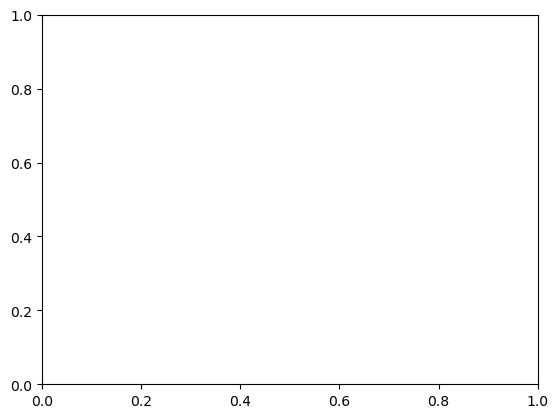

In [1]:
import pymc as pm
import pandas as pd
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import  pytensor.tensor as pt

import functionsSims as fs

In [4]:
data = pd.read_csv('../Data/SepulvedaNew/Pupil2022_FullData_Dec2022.csv')

# Low Clicks frame (`frame == 2`)

In [ ]:
data_part_all0 =  data.loc[data.frame == 2] # Low Clicks frame

data_part_all0 = data_part_all0.rename(columns = {'Choice':'ChosenITM','Choice_SND1_RT':'ChoiceRT' ,'CONF': 'Conf', 
                                                  'freql':'LValue','freqr':'RValue','part':'Part','Trial_Index_': 'TrialN' })

data_part_all0['AbsDV'] = np.abs(data_part_all0['LValue'] - data_part_all0['RValue'])
data_part_all0['zAbsDV'] = fs.zscore1(data_part_all0,'AbsDV', 'Part')

data_part_all0['TotVal'] = np.abs(data_part_all0['LValue'] + data_part_all0['RValue'])
data_part_all0['zTotVal'] = fs.zscore1(data_part_all0,'TotVal', 'Part')

# z-score values
data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LValue', 'Part')
data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RValue', 'Part')
data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Conf', 'Part')
data_part_all0['zRT'] = fs.zscore1(data_part_all0,'ChoiceRT', 'Part')

# estimate choice and confidence compound
data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.ChosenITM-1) # second term is to transform choice to left : -1; right: +1
data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

# Split trials: model fitted to even trials, odd trials kept as test set
data_part_all = data_part_all0.loc[data_part_all0.TrialN%2 == 0]
data_part_all_test = data_part_all0.loc[data_part_all0.TrialN%2 == 1]

# load input 
val_a = data_part_all.zLValue.values
val_b = data_part_all.zRValue.values
chosenByPart = data_part_all.ChosenITM.values
rtByPart = data_part_all.zRT.values

# generate all values to be sorted to generate high and low value distributions
value_sort = data_part_all.copy()
value_sort = value_sort.zLValue.values

confByPart = data_part_all.zConf.values
choiceConfByPart = data_part_all.zChoiceConf.values

confNormByPart = fs.norm01(data_part_all,'zConf','Part')

# Means of the low/high evidence distributions from a median split of the evidence (Figure S2)
lvalParam, hvalParam = fs.split_values_highLow (value_sort)

In [ ]:
delta_og = data_part_all.zLValue
delta_og.hist()
plt.title(r"Distribution of values from participant")
print('mean of the value distribution: ' + str(val_a.mean()))
print('std of the value distribution: ' + str(val_a.std()))
plt.show()

val_og = data_part_all.zLValue
conf_og = data_part_all.zConf
conf_og.hist()
plt.title(r"Distribution of confidence from participant (zScored)")
print('mean of the confidence distribution: ' + str(conf_og.mean()))
print('std of the confidence distribution: ' + str(conf_og.std()))
plt.show()

choiceConf_og = data_part_all0['Conf'] 
plt.hist(choiceConf_og)
plt.title(r"Distribution of zscored confidence from participant")
print('mean : ' + str(np.mean(choiceConf_og)))
print('std  : ' + str(np.std(choiceConf_og)))
plt.show()

choiceConf_og = confNormByPart
plt.hist(choiceConf_og)
plt.title(r"Distribution of normalized 0-1 confidence from participant")
print('mean : ' + str(np.mean(choiceConf_og)))
print('std  : ' + str(np.std(choiceConf_og)))
plt.show()

In [ ]:
n_trials = len (val_a)
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
for i in range(1):

    print ('running sim repetition '+ str(i) )
    
    with pm.Model() as model_peb2:
        # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
        sigmaGen1 = pm.Normal('sigmaBel1', mu=5, sigma=1) # low value distribution
        sigmaGen2 = pm.Normal('sigmaBel2', mu=5, sigma=1) # high value distribution
        
        # Observed (z-scored) evidence for the left/right option on each trial
        lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
        rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

        # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
        # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
        LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                       pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

        # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
        beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
        p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
        
        choice = pm.Bernoulli("choice", p, observed=chosenByPart)

        # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
        betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
        betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
        
        conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

        # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
        confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

# MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
nsample = 4000
nchains = 4
    

In [ ]:
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

In [14]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp4_soundLow_normalPrior.nc")

'sample_exp4_soundLow_normalPrior.nc'

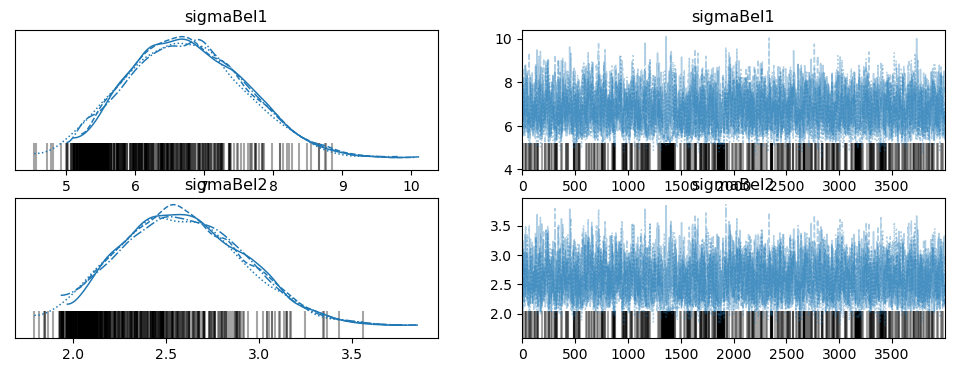

In [10]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=['sigmaBel1', 'sigmaBel2']);

In [11]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 1439, rVal_dim_0: 1439, LLR_dim_0: 1439,
                 p_dim_0: 1439, conf_dim_0: 1439)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 1433 1434 1435 1436 1437 1438
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 1433 1434 1435 1436 1437 1438
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 1433 1434 1435 1436 1437 1438
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 1433 1434 1435 1436 1437 1438
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 1433 1434 1435 1436 1437 1438
Data variables:
    sigmaBel1   float64 1.001
    sigmaBel2   float64 1.001
    lVal        (lVal_dim_0) float64 1.0 1.0 1.0 1.001 ... 1.001 1.001 1.002 1.0
    rVal        (rVal_dim_0) float64 1.0 1.001 1.001 1.001 ... 1.001 1.001 1.002
    beta        float64 1.001
    betaConf    float64 1.001
    betaRT      float64 1.002
    LLR         (LLR_dim_0) float64 1.003 1.003 1.003 ... 1.003 1.003 1.003
    p           (p_dim_0) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.001 1.0 1.001
    conf        (conf_dim_0) float64 1.001 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.001

Compare: Mean1 = 6.772864920585314; Mean2 = 2.5969047541021237; [mean1 - mean2] =  4.17596016648319; t =  1018.27 ; p-value =0.0


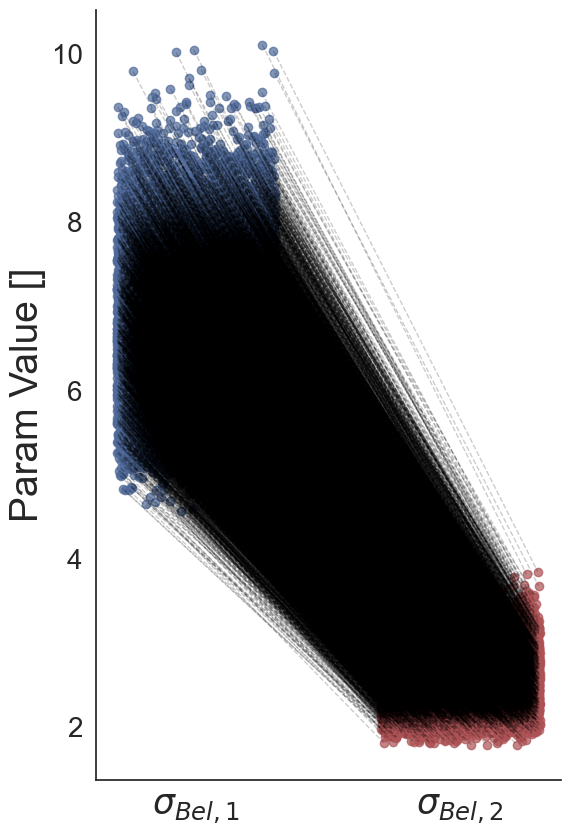

In [12]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

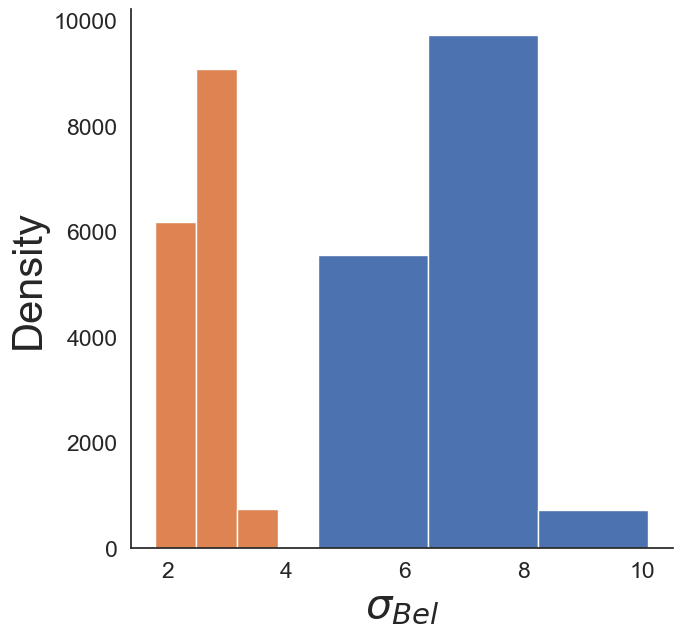

Proportion density above 0 : 0.0
Proportion density below 0 : 1.0
Mean sigmaBel1:6.772864920585314; SD sigmaBel1:0.8311692235170869
Mean sigmaBel2:2.5969047541021237; SD sigmaBel2:0.3261482734444996
Delta sigmaBel mean:-4.175960166483191; SD:0.5187299565371202


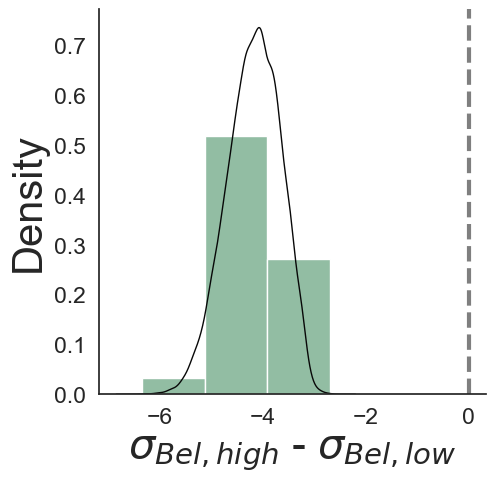

In [13]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = 'figures/PEB_Model1RT_sigmaBelDensityLowMo.svg')

# High Clicks frame (`frame == 1`)

mean values -> high: 0.5189653617301986 ,  low:-0.9114899485458068
stdev values -> high: 0.5189653617301986 ,  low:0.4737139737424027
low values distribution: mean:-0.9114899485458068, var:0.4737139737424027
high values distribution: mean:0.837461212727064, var:0.5189653617301986


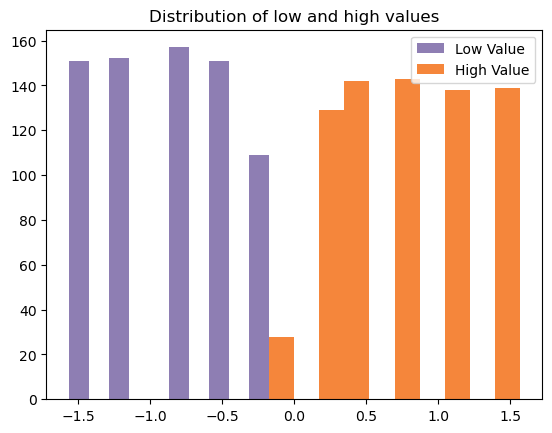

In [5]:
data_part_all0 =  data.loc[data.frame == 1] # High Clicks frame

data_part_all0 = data_part_all0.rename(columns = {'Choice':'ChosenITM','Choice_SND1_RT':'ChoiceRT' ,'CONF': 'Conf', 
                                                  'freql':'LValue','freqr':'RValue','part':'Part','Trial_Index_': 'TrialN' })

data_part_all0['AbsDV'] = np.abs(data_part_all0['LValue'] - data_part_all0['RValue'])
data_part_all0['zAbsDV'] = fs.zscore1(data_part_all0,'AbsDV', 'Part')

data_part_all0['TotVal'] = np.abs(data_part_all0['LValue'] + data_part_all0['RValue'])
data_part_all0['zTotVal'] = fs.zscore1(data_part_all0,'TotVal', 'Part')

# z-score values
data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LValue', 'Part')
data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RValue', 'Part')
data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Conf', 'Part')
data_part_all0['zRT'] = fs.zscore1(data_part_all0,'ChoiceRT', 'Part')

# estimate choice and confidence compound
data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.ChosenITM-1) # second term is to transform choice to left : -1; right: +1
data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

# Split trials: model fitted to even trials, odd trials kept as test set
data_part_all = data_part_all0.loc[data_part_all0.TrialN%2 == 0]
data_part_all_test = data_part_all0.loc[data_part_all0.TrialN%2 == 1]

# load input 
val_a = data_part_all.zLValue.values
val_b = data_part_all.zRValue.values
chosenByPart = data_part_all.ChosenITM.values
rtByPart = data_part_all.zRT.values

# generate all values to be sorted to generate high and low value distributions
value_sort = data_part_all.copy()
value_sort = value_sort.zLValue.values

confByPart = data_part_all.zConf.values
choiceConfByPart = data_part_all.zChoiceConf.values

confNormByPart = fs.norm01(data_part_all,'zConf','Part')

# Means of the low/high evidence distributions from a median split of the evidence (Figure S2)
lvalParam, hvalParam = fs.split_values_highLow (value_sort)

In [6]:
n_trials = len (val_a)
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
for i in range(1):

    print ('running sim repetition '+ str(i) )
    
    with pm.Model() as model_peb2:
        # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
        sigmaGen1 = pm.Normal('sigmaBel1', mu=5, sigma=1) # low value distribution
        sigmaGen2 = pm.Normal('sigmaBel2', mu=5, sigma=1) # high value distribution
        
        # Observed (z-scored) evidence for the left/right option on each trial
        lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
        rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

        # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
        # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
        LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                       pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

        # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
        beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
        p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
        
        choice = pm.Bernoulli("choice", p, observed=chosenByPart)

        # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
        betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
        betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
        
        conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

        # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
        confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

# MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
nsample = 4000
nchains = 4
    

running sim repetition 0


In [7]:
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

Sampling: [beta, betaConf, betaRT, choice, confReport, lVal, rVal, sigmaBel1, sigmaBel2]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaBel1, sigmaBel2, lVal, rVal, beta, betaConf, betaRT]


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 1520 seconds.


In [12]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp4_soundHigh_normalPrior.nc")

'sample_exp4_soundHigh_normalPrior.nc'

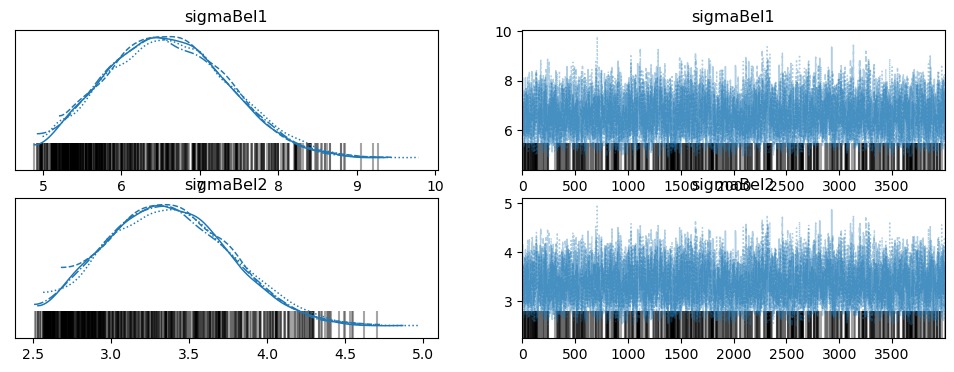

In [8]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=['sigmaBel1', 'sigmaBel2']);

In [9]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 1440, rVal_dim_0: 1440, LLR_dim_0: 1440,
                 p_dim_0: 1440, conf_dim_0: 1440)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 1434 1435 1436 1437 1438 1439
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 1434 1435 1436 1437 1438 1439
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 1434 1435 1436 1437 1438 1439
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 1434 1435 1436 1437 1438 1439
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 1434 1435 1436 1437 1438 1439
Data variables:
    sigmaBel1   float64 1.0
    sigmaBel2   float64 1.001
    lVal        (lVal_dim_0) float64 1.0 1.001 1.001 1.001 ... 1.001 1.0 1.0 1.0
    rVal        (rVal_dim_0) float64 1.0 1.0 1.0 1.001 ... 1.001 1.0 0.9999
    beta        float64 1.0
    betaConf    float64 1.0
    betaRT      float64 1.001
    LLR         (LLR_dim_0) float64 1.001 1.001 1.001 ... 1.001 1.001 1.001
    p           (p_dim_0) float64 1.002 1.001 1.001 1.001 ... 1.001 1.001 1.001
    conf        (conf_dim_0) float64 1.0 1.0 1.001 1.0 1.0 ... 1.0 1.0 1.001 1.0

Compare: Mean1 = 6.59785015863949; Mean2 = 3.3664924160082994; [mean1 - mean2] =  3.231357742631191; t =  1079.33 ; p-value =0.0


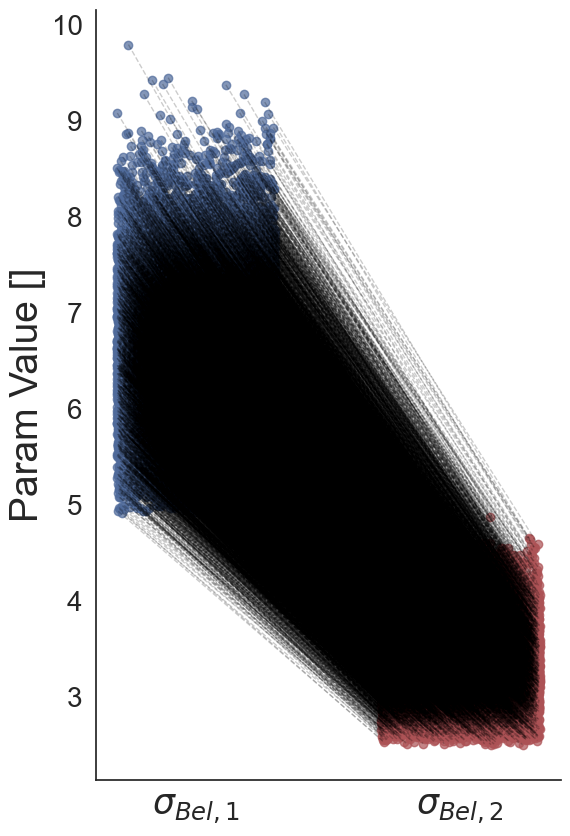

In [10]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

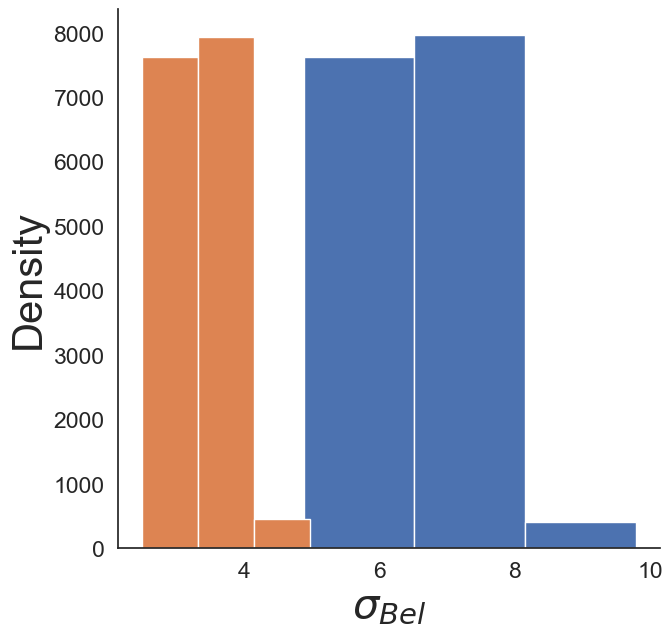

Proportion density above 0 : 0.0
Proportion density below 0 : 1.0
Mean sigmaBel1:6.59785015863949; SD sigmaBel1:0.7619251947849824
Mean sigmaBel2:3.3664924160082994; SD sigmaBel2:0.39078949852659417
Delta sigmaBel mean:-3.231357742631192; SD:0.3786838728824529


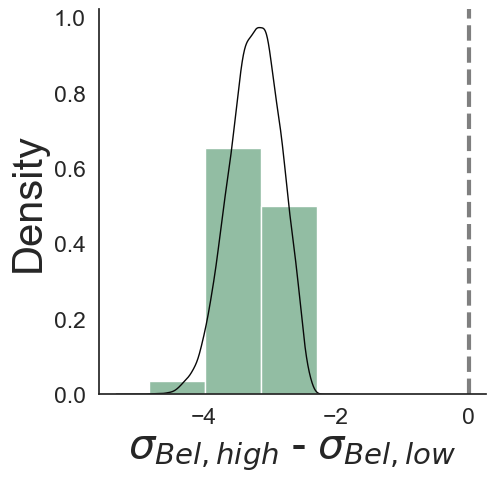

In [11]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = 'figures/PEB_Model1RT_sigmaBelDensityLowMo.svg')